In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import statsfuncs as ms
import matplotlib.pyplot as plt

Load SST Data

In [2]:
file_path = '../aug_ncData/ACCESS-CM3_1981-2030_ts.nc'
ds = xr.open_dataset(file_path)
ts0 = ds['ts']

Calculate the Nino indices and power spectra

In [3]:
df_nino34 = ms.compIndexF(ts0,['Nino3','Nino3.4']).T.to_pandas()
df_nino34.columns.rename('',inplace=True)
df_nino34_anom = ms.anomaly_df(ms.detrend_df(df_nino34))
df_spec34 = df_nino34_anom.apply(ms.spectrum,args=(7,'hanning'))
df_spec34.index *= 12   # cyc/month to cyc/year

Plot

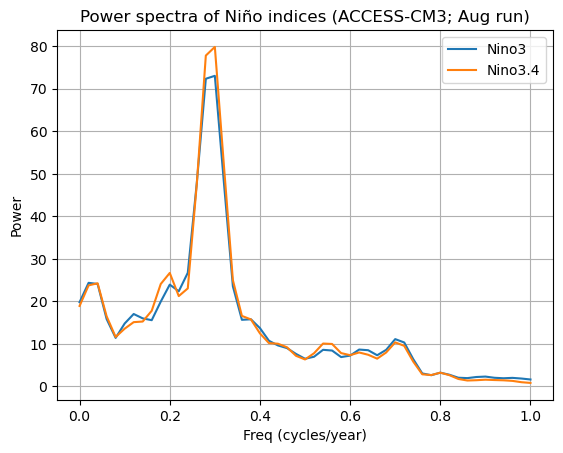

In [4]:
df_spec34.loc[:1].plot(grid=True)
plt.ylabel('Power')
plt.xlabel('Freq (cycles/year)')
plt.title('Power spectra of Niño indices (ACCESS-CM3; Aug run)')
#plt.savefig('Fig_specENSO_CM3_ts.png', format='png', dpi=1000, bbox_inches='tight')
#plt.show()

Apply 5-Month Running Mean

In [5]:
nino34_smoothed = df_nino34_anom['Nino3.4'].rolling(5, center=True).mean()
el_nino = nino34_smoothed.where(nino34_smoothed >= 0.5)
la_nina = nino34_smoothed.where(nino34_smoothed <= -0.5)

Plot Time Series

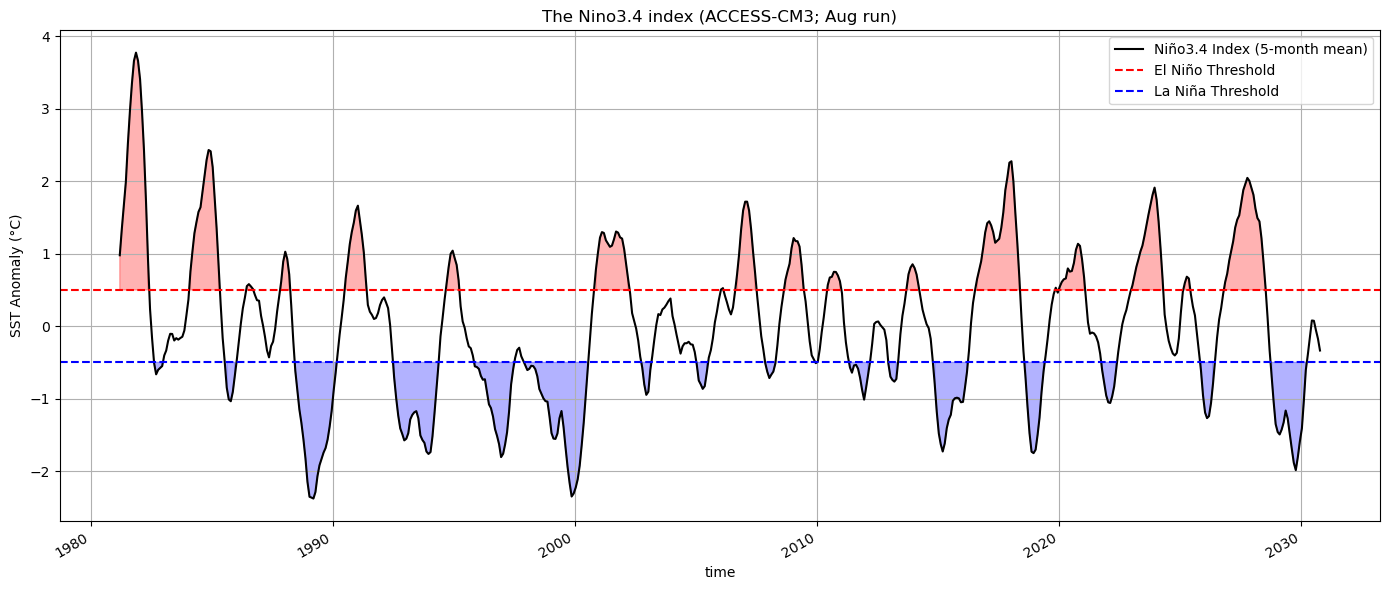

In [6]:
plt.figure(figsize=(14, 6))
nino34_smoothed.plot(label='Niño3.4 Index (5-month mean)', color='black')
plt.axhline(0.5, color='red', linestyle='--', label='El Niño Threshold')
plt.axhline(-0.5, color='blue', linestyle='--', label='La Niña Threshold')
plt.fill_between(nino34_smoothed.index, 0.5, nino34_smoothed, where=nino34_smoothed >= 0.5, color='red', alpha=0.3)
plt.fill_between(nino34_smoothed.index, -0.5, nino34_smoothed, where=nino34_smoothed <= -0.5, color='blue', alpha=0.3)
plt.title('The Nino3.4 index (ACCESS-CM3; Aug run)')
plt.ylabel('SST Anomaly (°C)')
plt.grid(True)
plt.legend()
plt.tight_layout()
#plt.savefig('Fig_ElNinoLaNina_CM3_ts.png', format='png', dpi=1000, bbox_inches='tight')
#plt.show()